In [2]:
#!pip install ipython-autotime
# %load_ext autotime

In [3]:
#import warnings
#warnings.simplefilter('module')

In [4]:
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import itertools
import random

## **Analysis Model for Performance/Reliability/Costl**

In [5]:
from ema_workbench import (RealParameter, IntegerParameter, ScalarOutcome, Constant, Model)
from ema_workbench import (MultiprocessingEvaluator, ema_logging, perform_experiments)
from ema_workbench.analysis import pairs_plotting
from ema_workbench.analysis import prim
from ema_workbench.analysis import feature_scoring
from ema_workbench.em_framework.evaluators import Samplers
from ema_workbench.em_framework.salib_samplers import get_SALib_problem
from ema_workbench import Policy
from ema_workbench import MultiprocessingEvaluator
from ema_workbench import save_results
from ema_workbench import load_results
from SALib.analyze import sobol

ema_logging.log_to_stderr(ema_logging.INFO)

<Logger EMA (DEBUG)>

Definition of the analysis functions.

In [6]:
def countActiveDevices(d1Services, d2Services, d3Services):
    count_activeDevices = 0
    if d1Services > 0:
        count_activeDevices = count_activeDevices + 1
    if d2Services > 0:
        count_activeDevices = count_activeDevices + 1
    if d3Services > 0:
        count_activeDevices = count_activeDevices + 1

    return count_activeDevices

def getTotalCost(d1Services, d2Services, d3Services, deviceCost, serviceCost):
    count_activeServices = d1Services + d2Services + d3Services
    count_activeDevices = countActiveDevices(d1Services, d2Services, d3Services)

    result = count_activeDevices*deviceCost + count_activeServices*serviceCost
    return result

# Test
getTotalCost(3,0,1,20,2)

48

In [7]:
def getExecutionTime(d1Services, d2Services, d3Services, lbExecTime, deviceCPUCyles, serviceFailureProb):
    count_activeDevices = countActiveDevices(d1Services, d2Services, d3Services)
    if count_activeDevices == 0:
        count_activeDevices = 1

    result = lbExecTime + (1 - serviceFailureProb/100) * 0.5 * deviceCPUCyles / count_activeDevices
    return math.ceil(result)

# Test
getExecutionTime(3,0,1,10,120,30)

31

In [8]:
def getProbabilitySuccessfulExecution(d1Services, d2Services, d3Services, lbFailureProb, serviceFailureProb):
    count_activeDevices = countActiveDevices(d1Services, d2Services, d3Services)

    result = 100 * (1 - lbFailureProb/100) * (1 - math.pow(serviceFailureProb/100, count_activeDevices))
    return math.ceil(result)

# Test
getProbabilitySuccessfulExecution(3,0,1,20,30)

73

Model definition.

In [9]:
# Constants (default values)
Default_deviceCost = 20
Default_serviceCost = 2
Default_lbExectTime = 30
Default_deviceCPUCyles = 120
Default_lbFailureProb = 20
Default_serviceFailureProb = 30
Default_dServices = 1

def modelFunction(d1Services= Default_dServices,
                  d2Services= Default_dServices,
                  d3Services= Default_dServices,
                  deviceCost = Default_deviceCost,
                  serviceCost = Default_serviceCost,
                  lbExecTime = Default_lbExectTime,
                  deviceCPUCyles = Default_deviceCPUCyles,
                  serviceFailureProb = Default_serviceFailureProb,
                  lbFailureProb = Default_lbFailureProb):

    cost = getTotalCost(d1Services, d2Services, d3Services, deviceCost, serviceCost)
    executionTime = getExecutionTime(d1Services, d2Services, d3Services, lbExecTime, deviceCPUCyles, serviceFailureProb)
    probSuccessfulExecution = getProbabilitySuccessfulExecution(d1Services, d2Services, d3Services, lbFailureProb, serviceFailureProb)

    # Outcomes
    return cost, executionTime, probSuccessfulExecution

# Test
#modelFunction(2,1,0,20,2,10,120,30, 20)
modelFunction(2,1,0)

(46, 51, 73)

### **Sampling (dataset)**

In [10]:
model = Model('archexploration', function=modelFunction)

#specify uncertainties
model.uncertainties = [IntegerParameter('deviceCost', 0, 40),
                       IntegerParameter('serviceCost', 1, 5),
                       IntegerParameter('lbExecTime', 10, 50),
                       IntegerParameter('deviceCPUCyles', 100, 150),
                       IntegerParameter('serviceFailureProb', 10, 50),
                       IntegerParameter('lbFailureProb', 10, 50)]

# set levers
model.levers = [IntegerParameter("d1Services", 0, 6),
                IntegerParameter("d2Services", 0, 6),
                IntegerParameter("d3Services", 0, 6)]

#specify outcomes
model.outcomes = [ScalarOutcome('cost'),
                  ScalarOutcome('executionTime'),
                  ScalarOutcome('probSuccessfulExecution')]

In [11]:
#with MultiprocessingEvaluator(model) as evaluator:
#    results = evaluator.perform_experiments(scenarios=100, policies=10)
results = perform_experiments(models=model, scenarios=500, policies=400, 
                              lever_sampling=Samplers.FF) # Full factorial for levers

[MainProcess/INFO] performing 500 scenarios * 343 policies * 1 model(s) = 171500 experiments
100%|████████████████████████████████| 171500/171500 [01:06<00:00, 2583.20it/s]
[MainProcess/INFO] experiments finished


In [12]:
save_results(results, './data/archexploration_500scenarios_400policies_ff.tar.gz')
#results = load_results('./data/archexploration_500scenarios_350policies.tar.gz')

[MainProcess/INFO] results saved successfully to /Users/adiazpace/Documents/my-research/performance-models-cdp/Toy_Example/data/archexploration_500scenarios_400policies_ff.tar.gz


In [18]:
# Fix configuration for specific parameters (no uncertainties)
model.uncertainties = [IntegerParameter('deviceCost', 0, 20), # Sobol
                       IntegerParameter('serviceCost', 1, 4), # Sobol
                       IntegerParameter('lbExecTime', 10, 37), # Sobol
                       IntegerParameter('deviceCPUCyles', 100, 150),
                       IntegerParameter('serviceFailureProb', 10, 50),
                       IntegerParameter('lbFailureProb', 10, 33)] # Sobol

# set levers
model.levers = [IntegerParameter("d1Services", 2, 2), # This is selecting only 1 alternative!
                IntegerParameter("d2Services", 5, 5),
                IntegerParameter("d3Services", 1, 1)]

results = perform_experiments(models=model, scenarios=500, policies=1)
save_results(results, './data/archexploration_500scenarios_1policies_sobol.tar.gz')

[MainProcess/INFO] performing 500 scenarios * 1 policies * 1 model(s) = 500 experiments
100%|██████████████████████████████████████| 500/500 [00:00<00:00, 3532.56it/s]
[MainProcess/INFO] experiments finished
[MainProcess/INFO] results saved successfully to /Users/adiazpace/Documents/my-research/explainability-cmu/robustness/data/archexploration_500scenarios_1policies_sobol.tar.gz


time: 192 ms (started: 2023-12-16 22:17:30 -03:00)


In [13]:
results = load_results('./data/archexploration_500scenarios_400policies_ff.tar.gz')

[MainProcess/INFO] results loaded successfully from /Users/adiazpace/Documents/my-research/performance-models-cdp/Toy_Example/data/archexploration_500scenarios_400policies_ff.tar.gz


In [14]:
experiments_df, outcomes_dict = results
policies = experiments_df['policy']
print(experiments_df.shape)
print(list(outcomes_dict.keys()))

(171500, 12)
['cost', 'executionTime', 'probSuccessfulExecution']


In [15]:
config_0_0_0_to_remove = experiments_df[(experiments_df.d1Services==0)&(experiments_df.d2Services==0)&(experiments_df.d3Services==0)].index
experiments_df.drop(experiments_df.index[config_0_0_0_to_remove], inplace=True)
experiments_df.reset_index(drop=True, inplace=True)
experiments_df.head()

,deviceCPUCyles,deviceCost,lbExecTime,lbFailureProb,serviceCost,serviceFailureProb,d1Services,d2Services,d3Services,scenario,policy,model
0,109,23,49,27,5,18,0,0,1,343,1,archexploration
1,138,15,18,22,4,10,0,0,1,344,1,archexploration
2,104,21,44,30,3,48,0,0,1,345,1,archexploration
3,109,12,11,15,3,36,0,0,1,346,1,archexploration
4,147,13,11,18,1,27,0,0,1,347,1,archexploration


In [17]:
experiments_df.describe()

,deviceCPUCyles,deviceCost,lbExecTime,lbFailureProb,serviceCost,serviceFailureProb,d1Services,d2Services,d3Services
count,171000.000000,171000.00000,171000.000000,171000.000000,171000.000000,171000.000000,171000.000000,171000.000000,171000.000000
mean,124.992000,19.99800,30.002000,30.004000,3.000000,30.004000,3.008772,3.008772,3.008772
std,14.711533,11.83701,11.833124,11.838446,1.414218,11.834222,1.996328,1.996328,1.996328
min,100.000000,0.00000,10.000000,10.000000,1.000000,10.000000,0.000000,0.000000,0.000000
25%,112.000000,10.00000,20.000000,20.000000,2.000000,20.000000,1.000000,1.000000,1.000000
50%,125.000000,20.00000,30.000000,30.000000,3.000000,30.000000,3.000000,3.000000,3.000000
75%,138.000000,30.00000,40.000000,40.000000,4.000000,40.000000,5.000000,5.000000,5.000000
max,150.000000,40.00000,50.000000,50.000000,5.000000,50.000000,6.000000,6.000000,6.000000


In [18]:
outcomes_df = pd.DataFrame(outcomes_dict)
outcomes_df.drop(outcomes_df.index[config_0_0_0_to_remove], inplace=True)
outcomes_df.reset_index(drop=True, inplace=True)
outcomes_df.head()

,cost,executionTime,probSuccessfulExecution
0,28,94,60
1,19,81,71
2,24,72,37
3,15,46,55
4,14,65,60


In [19]:
outcomes_df.describe()

,cost,executionTime,probSuccessfulExecution
count,171000.000000,171000.000000,171000.000000
mean,78.652737,48.877789,65.293895
std,39.993494,14.227972,12.421094
min,1.000000,22.000000,26.000000
25%,47.000000,38.000000,55.000000
50%,75.000000,48.000000,65.000000
75%,106.000000,59.000000,75.000000
max,210.000000,114.000000,90.000000


In [20]:
def filter_architecture(experiments, outcomes, dServices):
    d1Services = dServices[0]
    d2Services = dServices[1]
    d3Services = dServices[2]
    exp_filter = experiments[(experiments['d1Services']==d1Services)&(experiments['d2Services']==d2Services)&(experiments['d3Services']==d3Services)]
    policy = exp_filter['policy'].unique()
    #print('policies:', policy)
    if len(policy) > 0:
        exp_filter = exp_filter[exp_filter['policy'] == policy[0]]
    exp_outcomes = dict()
    for k in outcomes.keys():
        exp_outcomes[k] = outcomes[k][exp_filter.index]
    
    return exp_filter, exp_outcomes

Check if all configurations (levers) were sampled.

In [21]:
#OPTIONS = [[1, 2, 3], [4, 5, 6], [0, 1, 2]]
#OPTIONS = [[0, 1, 2, 3], [3, 4, 5, 6], [0, 1, 2, 3]]
OPTIONS = [list(range(7)), list(range(7)), list(range(7))]

all_combinations = [list(x) for x in itertools.product(*OPTIONS)]
#config = random.choice(all_combinations)
#print(config, "configuation, out of", len(all_combinations), "combinations (policies)")

for c in all_combinations:
    exp_filtered, exp_outcomes = filter_architecture(experiments_df, outcomes_dict, c)
    if exp_filtered.shape[0] == 0:
        print("Warning: configuration", c, "was not sampled!")

### **Feature scoring (w.r.t. outcomes)**

In [22]:
x = experiments_df
y = outcomes_dict

fs = feature_scoring.get_feature_scores_all(x, y) #, mode=feature_scoring.CLASSIFICATION)
sns.heatmap(fs, cmap='viridis', annot=True)
#plt.savefig('feature-scoring1.png')
plt.show()

ValueError: Found input variables with inconsistent numbers of samples: [171000, 171500]

In [49]:
fs

,cost,executionTime,probSuccessfulExecution
0,,,
d1Services,0.049984,0.046535,0.029318
d2Services,0.075195,0.060567,0.040904
d3Services,0.081635,0.067178,0.045576
deviceCPUCyles,0.006731,0.029891,0.016262
deviceCost,0.575290,0.014286,0.017487
lbExecTime,0.006127,0.649762,0.015954
lbFailureProb,0.006312,0.014513,0.680738
policy,0.065625,0.050524,0.050804
serviceCost,0.126344,0.012273,0.013037


time: 11.5 ms (started: 2023-12-16 22:26:26 -03:00)


In [50]:
fs.sort_values(ascending=False, by='cost')['cost'] # Example of ordering by cost

0
deviceCost            0.575290
serviceCost           0.126344
d3Services            0.081635
d2Services            0.075195
policy                0.065625
d1Services            0.049984
serviceFailureProb    0.006756
deviceCPUCyles        0.006731
lbFailureProb         0.006312
lbExecTime            0.006127
Name: cost, dtype: float64

time: 8.55 ms (started: 2023-12-16 22:26:29 -03:00)


### **Sensitivity analysis (w.r.t. outcomes)**

In [52]:
sa_results = perform_experiments(models=model, scenarios=128, policies=128,
                                 lever_sampling= Samplers.SOBOL,
                                 uncertainty_sampling= Samplers.SOBOL)

sa_experiments_df, sa_outcomes_dict = sa_results

[MainProcess/INFO] performing 1792 scenarios * 1024 policies * 1 model(s) = 1835008 experiments
100%|██████████████████████████████| 1835008/1835008 [08:26<00:00, 3621.01it/s]
[MainProcess/INFO] experiments finished


time: 8min 27s (started: 2023-12-16 22:27:04 -03:00)


In [54]:
sa_experiments_df.head()

,deviceCPUCyles,deviceCost,lbExecTime,lbFailureProb,serviceCost,serviceFailureProb,d1Services,d2Services,d3Services,scenario,policy,model
0,148,9,16,23,2,16,2,5,1,2368,1344,archexploration
1,145,9,16,23,2,16,2,5,1,2369,1344,archexploration
2,148,0,16,23,2,16,2,5,1,2370,1344,archexploration
3,148,9,17,23,2,16,2,5,1,2371,1344,archexploration
4,148,9,16,32,2,16,2,5,1,2372,1344,archexploration


time: 13.9 ms (started: 2023-12-16 22:35:48 -03:00)


In [56]:
# For parameters
uncertainties_problem = get_SALib_problem(model.uncertainties)
print('----', 'executionTime')
Si_1 = sobol.analyze(uncertainties_problem, sa_outcomes_dict['executionTime'], calc_second_order=True, print_to_console=True)
print('----', 'probSuccessfulExecution')
Si_2 = sobol.analyze(uncertainties_problem, sa_outcomes_dict['probSuccessfulExecution'], calc_second_order=True, print_to_console=True)
print('----', 'cost')
Si_3 = sobol.analyze(uncertainties_problem, sa_outcomes_dict['cost'], calc_second_order=True, print_to_console=True)

---- executionTime
                          ST   ST_conf
deviceCPUCyles      0.041016  0.000304
deviceCost          0.000000  0.000000
lbExecTime          0.877425  0.005324
lbFailureProb       0.000000  0.000000
serviceCost         0.000000  0.000000
serviceFailureProb  0.089499  0.000766
                          S1   S1_conf
deviceCPUCyles      0.037155  0.001551
deviceCost          0.000000  0.000000
lbExecTime          0.880581  0.006672
lbFailureProb       0.000000  0.000000
serviceCost         0.000000  0.000000
serviceFailureProb  0.088703  0.002358
                                            S2       S2_conf
(deviceCPUCyles, deviceCost)          0.000826  2.125756e-03
(deviceCPUCyles, lbExecTime)          0.005138  3.263957e-03
(deviceCPUCyles, lbFailureProb)       0.000826  2.125756e-03
(deviceCPUCyles, serviceCost)         0.000826  2.125756e-03
(deviceCPUCyles, serviceFailureProb)  0.009661  2.148035e-03
(deviceCost, lbExecTime)              0.000000  0.000000e+00
(deviceC

In [57]:
def show_sobol(problem, Si, title='', filename=None):
    scores_filtered = {k:Si[k] for k in ['ST','ST_conf','S1','S1_conf']}
    Si_df = pd.DataFrame(scores_filtered, index=problem['names'])

    sns.set_style('white')
    fig, ax = plt.subplots(1)

    indices = Si_df[['S1','ST']]
    err = Si_df[['S1_conf','ST_conf']]

    indices.plot.bar(yerr=err.values.T,ax=ax)
    fig.set_size_inches(8,6)
    fig.subplots_adjust(bottom=0.3)
    plt.title(title)
    if filename is not None:
        plt.savefig(filename)
    plt.show()

time: 779 µs (started: 2023-12-16 22:38:16 -03:00)


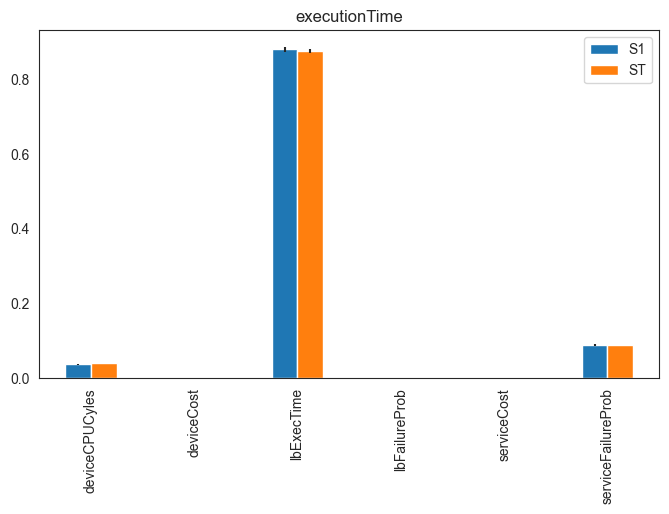

time: 268 ms (started: 2023-12-16 22:42:37 -03:00)


In [58]:
show_sobol(uncertainties_problem, Si_1, title='executionTime') #, filename='./data/sobol_executiontime1.png')

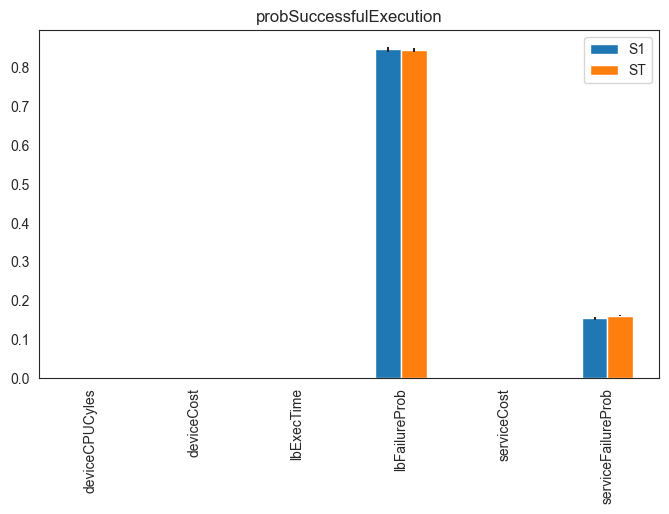

time: 216 ms (started: 2023-12-16 22:42:41 -03:00)


In [59]:
show_sobol(uncertainties_problem, Si_2, title='probSuccessfulExecution') #, filename='./data/sobol_probsuccessfulexecution1.png')

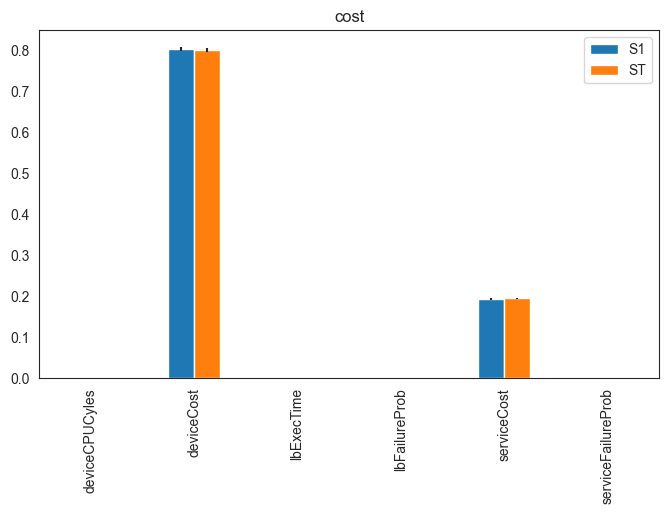

time: 216 ms (started: 2023-12-16 22:42:44 -03:00)


In [60]:
show_sobol(uncertainties_problem, Si_3, title='cost') #, filename='./data/sobol_cost1.png')

In [61]:
# For levers
levers_problem = get_SALib_problem(model.levers)
print('----', 'executionTime')
Si_4 = sobol.analyze(levers_problem, sa_outcomes_dict['executionTime'], calc_second_order=True, print_to_console=True)
print('----', 'probSuccessfulExecution')
Si_5 = sobol.analyze(levers_problem, sa_outcomes_dict['probSuccessfulExecution'], calc_second_order=True, print_to_console=True)
print('----', 'cost')
Si_6 = sobol.analyze(levers_problem, sa_outcomes_dict['cost'], calc_second_order=True, print_to_console=True)

---- executionTime
                  ST   ST_conf
d1Services  0.301465  0.002972
d2Services  0.306910  0.003098
d3Services  0.322484  0.003150
                  S1   S1_conf
d1Services  0.169581  0.003728
d2Services  0.308648  0.003966
d3Services  0.304103  0.003970
                                S2   S2_conf
(d1Services, d2Services) -0.046547  0.005561
(d1Services, d3Services) -0.111518  0.005553
(d2Services, d3Services) -0.708548  0.007991
---- probSuccessfulExecution
                  ST   ST_conf
d1Services  0.393671  0.003538
d2Services  0.797298  0.004569
d3Services  0.423713  0.003464
                  S1   S1_conf
d1Services  0.100630  0.004234
d2Services  0.285197  0.005213
d3Services  0.369818  0.003984
                                S2   S2_conf
(d1Services, d2Services) -0.213758  0.006951
(d1Services, d3Services)  0.038119  0.007182
(d2Services, d3Services)  0.012919  0.006268
---- cost
                  ST   ST_conf
d1Services  0.435761  0.003874
d2Services  0.523499  0.

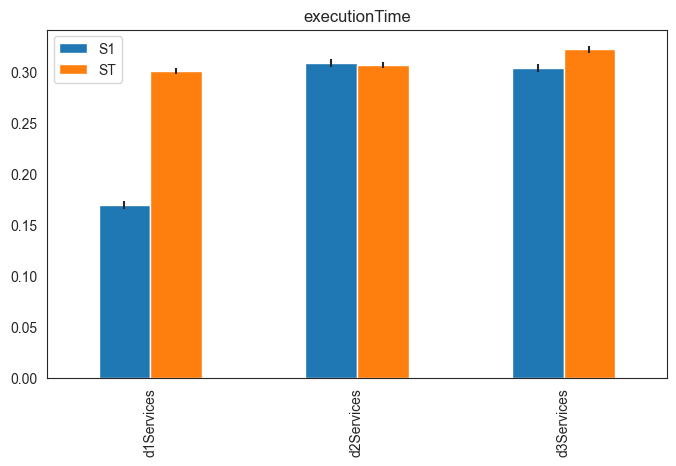

time: 187 ms (started: 2023-12-16 22:44:51 -03:00)


In [62]:
show_sobol(levers_problem, Si_4, title='executionTime')

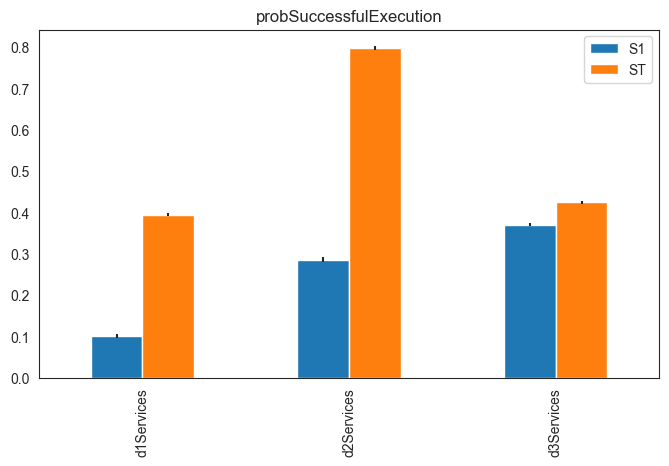

time: 223 ms (started: 2023-12-16 22:44:55 -03:00)


In [63]:
show_sobol(levers_problem, Si_5, title='probSuccessfulExecution')

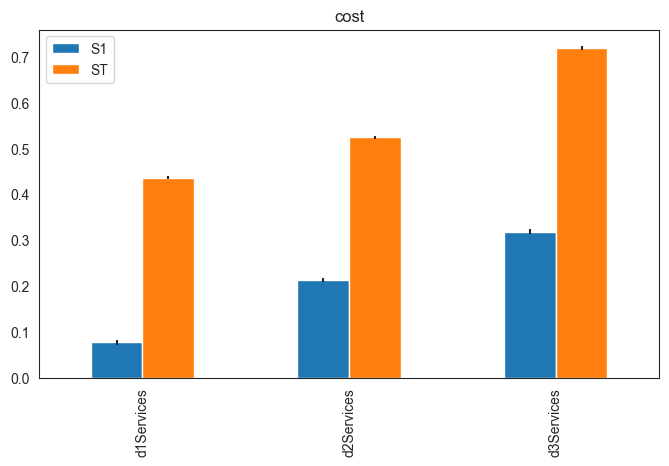

time: 187 ms (started: 2023-12-16 22:44:58 -03:00)


In [64]:
show_sobol(levers_problem, Si_6, title='cost')

---